In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.



  NVDA: 2513 rows
  AAPL: 2513 rows
  SPY: 2513 rows
  CBA.AX: 2529 rows
  BHP.AX: 2529 rows
  CSL.AX: 2529 rows

  RSI STRATEGY — FULL COMPARISON TABLE
                     B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  B&H Max DD %  Strat Max DD %  Win Rate %
Ticker RSI Params                                                                                                                                       
AAPL   RSI14(20/80)              945.59                230.36                  12.74        0.92          0.76        -38.52          -23.38       54.24
       RSI14(25/75)              945.59                228.66                  12.68        0.92          0.61        -38.52          -29.68       55.30
       RSI14(30/70)              945.59                157.45                   9.95        0.92          0.48        -38.52          -29.94       53.80
       RSI14(35/65)              945.59                223.90                  12

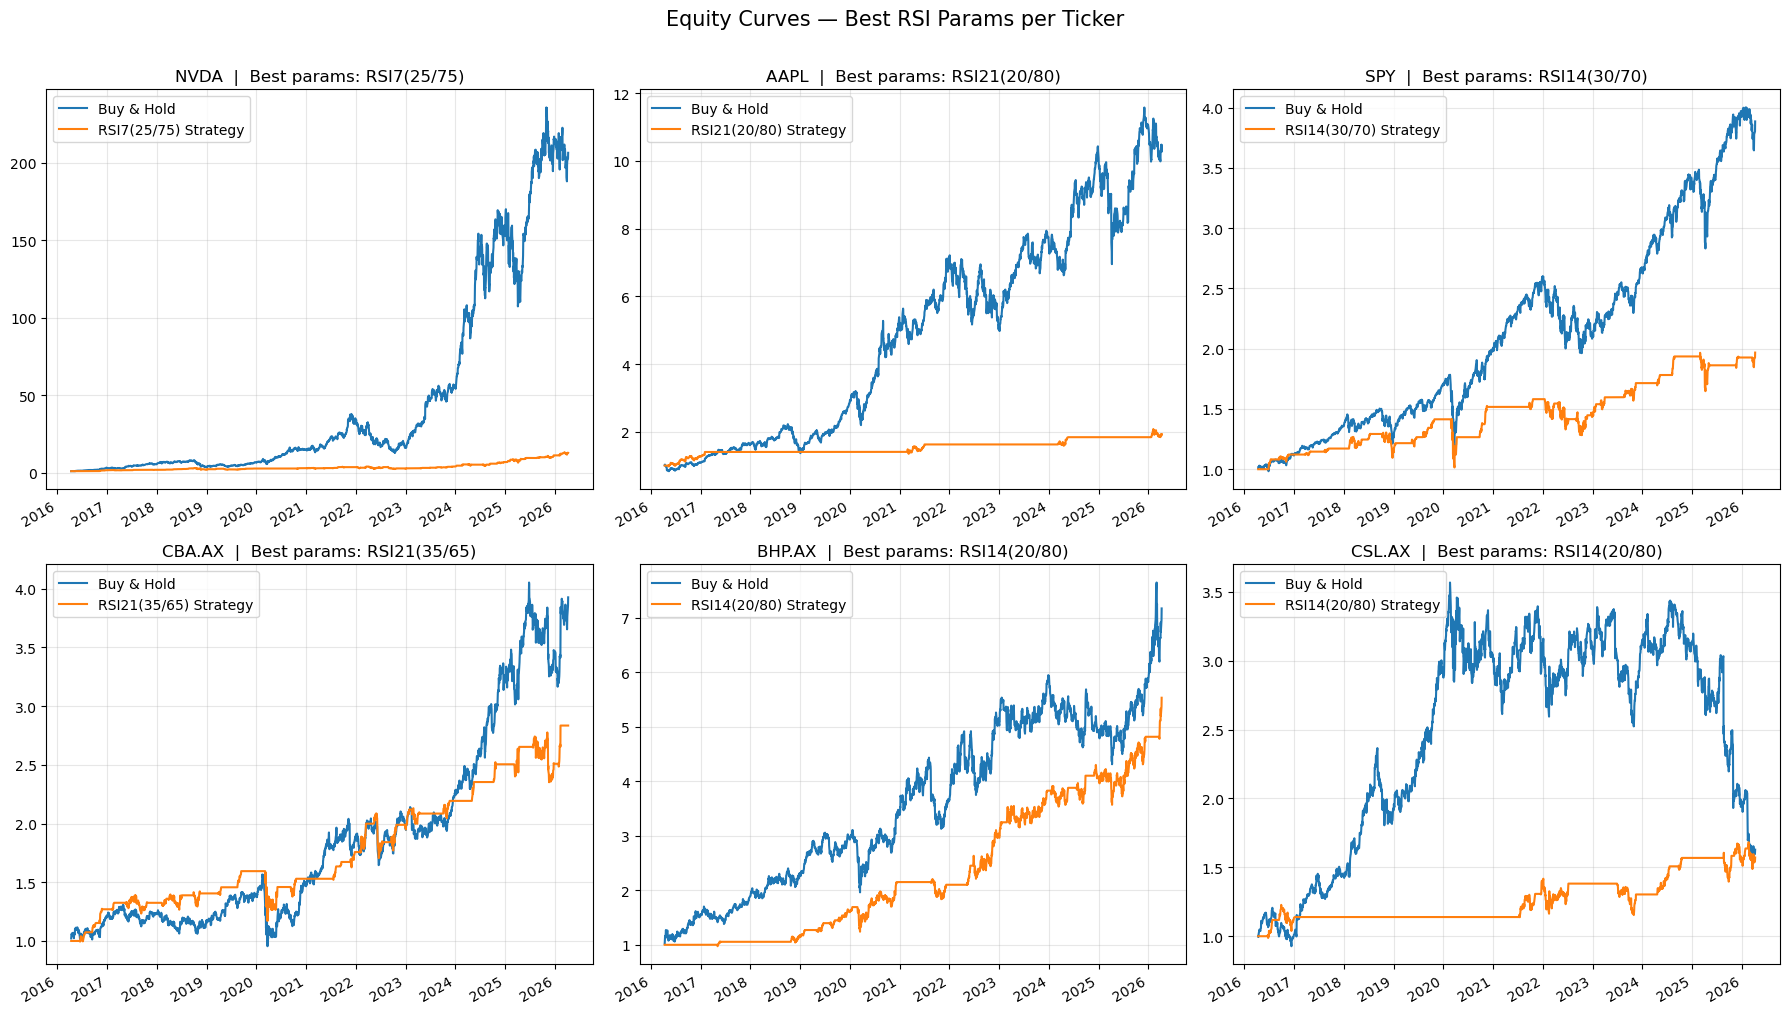


Chart saved as rsi_best_equity_curves.png


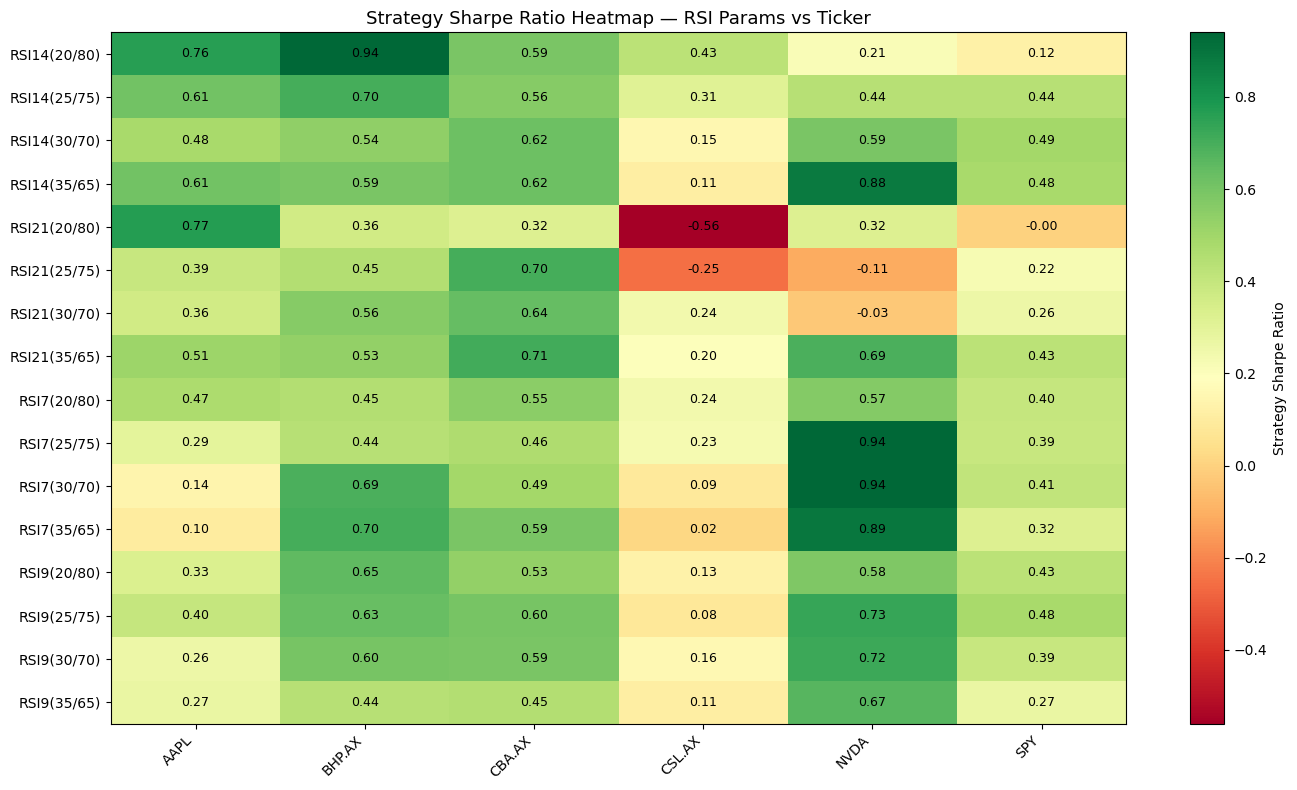

Heatmap saved as rsi_sharpe_heatmap.png


In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# ── Configuration ──────────────────────────────────────────────────────────────
endDate   = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365 * 10)

stocks = ["NVDA", "AAPL", "SPY", "CBA.AX", "BHP.AX", "CSL.AX"]

# RSI parameter combos to test: (period, overbought_threshold, oversold_threshold)
# RSI < oversold  → beaten down → buy signal
# RSI > overbought → run up hard → exit signal
rsi_periods = [7, 9, 14, 21]
ob_os_pairs = [(70, 30), (65, 35), (75, 25), (80, 20)]
rsi_params  = [(p, ob, os) for p in rsi_periods for ob, os in ob_os_pairs]

# 252 trading days/year for stocks; crypto trades 365 but 252 is fine for comparison
PERIODS_PER_YEAR = 252


# ── Helper: compute RSI ────────────────────────────────────────────────────────
# RSI measures momentum: 100 - (100 / (1 + RS))
# RS = average gain / average loss over `period` days
def compute_rsi(price_series, period):
    delta    = price_series.diff()
    gain     = delta.where(delta > 0, 0.0)
    loss     = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs       = avg_gain / avg_loss
    rsi      = 100 - (100 / (1 + rs))
    return rsi


# ── Helper: run a single RSI backtest ─────────────────────────────────────────
def run_backtest(price_series, period, overbought, oversold):
    df = pd.DataFrame({"price": price_series})
    df["RSI"] = compute_rsi(df["price"], period)

    # Raw signals: 1 = buy when oversold, 0 = exit when overbought
    # NaN in between → forward-fill to hold position
    df["raw_signal"] = np.nan
    df.loc[df["RSI"] < oversold,   "raw_signal"] = 1   # oversold  → go long
    df.loc[df["RSI"] > overbought, "raw_signal"] = 0   # overbought → exit

    df["signal"]   = df["raw_signal"].ffill().fillna(0)
    df["position"] = df["signal"].shift(1)              # act the day after signal

    df["log_returns"]          = np.log(df["price"] / df["price"].shift(1))
    df["strategy_log_returns"] = df["position"] * df["log_returns"]

    df["cum_market"]   = np.exp(df["log_returns"].cumsum())
    df["cum_strategy"] = np.exp(df["strategy_log_returns"].cumsum())
    return df


# ── Helper: max drawdown ───────────────────────────────────────────────────────
def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    drawdown    = (cum_series - running_max) / running_max
    return drawdown.min()


# ── Helper: compute all metrics for one backtest run ──────────────────────────
def get_metrics(df):
    market_lr   = df["log_returns"].dropna()
    strategy_lr = df["strategy_log_returns"].dropna()

    total_mkt   = df["cum_market"].dropna().iloc[-1]   - 1
    total_strat = df["cum_strategy"].dropna().iloc[-1] - 1

    ann_mkt     = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat   = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1

    vol_mkt     = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat   = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)

    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan

    mdd_mkt   = max_drawdown(df["cum_market"].dropna())
    mdd_strat = max_drawdown(df["cum_strategy"].dropna())

    winning_days = (strategy_lr > 0).sum()
    total_days   = (strategy_lr != 0).sum()
    win_rate     = winning_days / total_days if total_days > 0 else np.nan

    return {
        "B&H Total Return %":    round(total_mkt   * 100, 2),
        "Strat Total Return %":  round(total_strat * 100, 2),
        "Strat Annual Return %": round(ann_strat   * 100, 2),
        "B&H Sharpe":            round(sharpe_mkt,   2),
        "Strat Sharpe":          round(sharpe_strat, 2),
        "B&H Max DD %":          round(mdd_mkt   * 100, 2),
        "Strat Max DD %":        round(mdd_strat * 100, 2),
        "Win Rate %":            round(win_rate   * 100, 2),
    }


# ── Step 1: Download price data (once per ticker) ─────────────────────────────
print("Downloading price data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=startDate, end=endDate, auto_adjust=True, progress=False)
    price_data[stock] = raw["Close"].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Run all RSI param × stock combinations ────────────────────────────
all_results = []

for period, overbought, oversold in rsi_params:
    for stock in stocks:
        df      = run_backtest(price_data[stock], period, overbought, oversold)
        metrics = get_metrics(df)
        metrics["Ticker"]     = stock
        metrics["RSI Params"] = f"RSI{period}({oversold}/{overbought})"
        all_results.append(metrics)


# ── Step 3: Build the comparison table ────────────────────────────────────────
results_df = (
    pd.DataFrame(all_results)
    .set_index(["Ticker", "RSI Params"])
    .sort_index()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("\n" + "=" * 100)
print("  RSI STRATEGY — FULL COMPARISON TABLE")
print("=" * 100)
print(results_df.to_string())


# ── Step 4: Best RSI params per stock (by Strategy Sharpe) ────────────────────
reset    = results_df.reset_index()
best_idx = reset.groupby("Ticker")["Strat Sharpe"].idxmax()
best     = reset.loc[best_idx, ["Ticker", "RSI Params", "Strat Sharpe",
                                  "Strat Total Return %", "Strat Max DD %", "Win Rate %"]]
best     = best.set_index("Ticker")

print("\n" + "=" * 100)
print("  BEST RSI PARAMS PER TICKER  (ranked by Strategy Sharpe Ratio)")
print("=" * 100)
print(best.to_string())


# ── Step 5: Equity curves — best RSI params per stock ─────────────────────────
best_params = best["RSI Params"].to_dict()

n_stocks = len(stocks)
cols = 3
rows = (n_stocks + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

import re

for i, stock in enumerate(stocks):
    ax        = axes[i]
    param_str = best_params[stock]
    m         = re.match(r"RSI(\d+)\((\d+)/(\d+)\)", param_str)
    period     = int(m.group(1))
    oversold   = int(m.group(2))
    overbought = int(m.group(3))

    df = run_backtest(price_data[stock], period, overbought, oversold)
    df[["cum_market", "cum_strategy"]].plot(ax=ax)

    ax.set_title(f"{stock}  |  Best params: {param_str}", fontsize=12)
    ax.set_xlabel("")
    ax.legend(["Buy & Hold", f"{param_str} Strategy"])
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Equity Curves — Best RSI Params per Ticker", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("rsi_best_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as rsi_best_equity_curves.png")


# ── Step 6: Strategy Sharpe heatmap (RSI params vs Ticker) ────────────────────
sharpe_pivot = reset.pivot(index="RSI Params", columns="Ticker", values="Strat Sharpe")

fig2, ax2 = plt.subplots(figsize=(14, 8))
im = ax2.imshow(sharpe_pivot.values, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax2, label="Strategy Sharpe Ratio")

ax2.set_xticks(range(len(sharpe_pivot.columns)))
ax2.set_xticklabels(sharpe_pivot.columns, rotation=45, ha="right")
ax2.set_yticks(range(len(sharpe_pivot.index)))
ax2.set_yticklabels(sharpe_pivot.index)
ax2.set_title("Strategy Sharpe Ratio Heatmap — RSI Params vs Ticker", fontsize=13)

for row_i in range(len(sharpe_pivot.index)):
    for col_j in range(len(sharpe_pivot.columns)):
        val = sharpe_pivot.values[row_i, col_j]
        if not np.isnan(val):
            ax2.text(col_j, row_i, f"{val:.2f}", ha="center", va="center",
                     fontsize=9, color="black")

plt.tight_layout()
plt.savefig("rsi_sharpe_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as rsi_sharpe_heatmap.png")



  NVDA — All RSI Params Compared
              B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  B&H Max DD %  Strat Max DD %  Win Rate %
RSI Params                                                                                                                                       
RSI14(20/80)            20546.74                 73.51                   5.68        1.43          0.21        -66.34          -60.80       54.91
RSI14(25/75)            20546.74                204.45                  11.82        1.43          0.44        -66.34          -56.68       55.33
RSI14(30/70)            20546.74                356.35                  16.45        1.43          0.59        -66.34          -53.57       56.10
RSI14(35/65)            20546.74               1110.19                  28.42        1.43          0.88        -66.34          -54.06       56.47
RSI21(20/80)            20546.74                 80.75                   6.12        1.43 

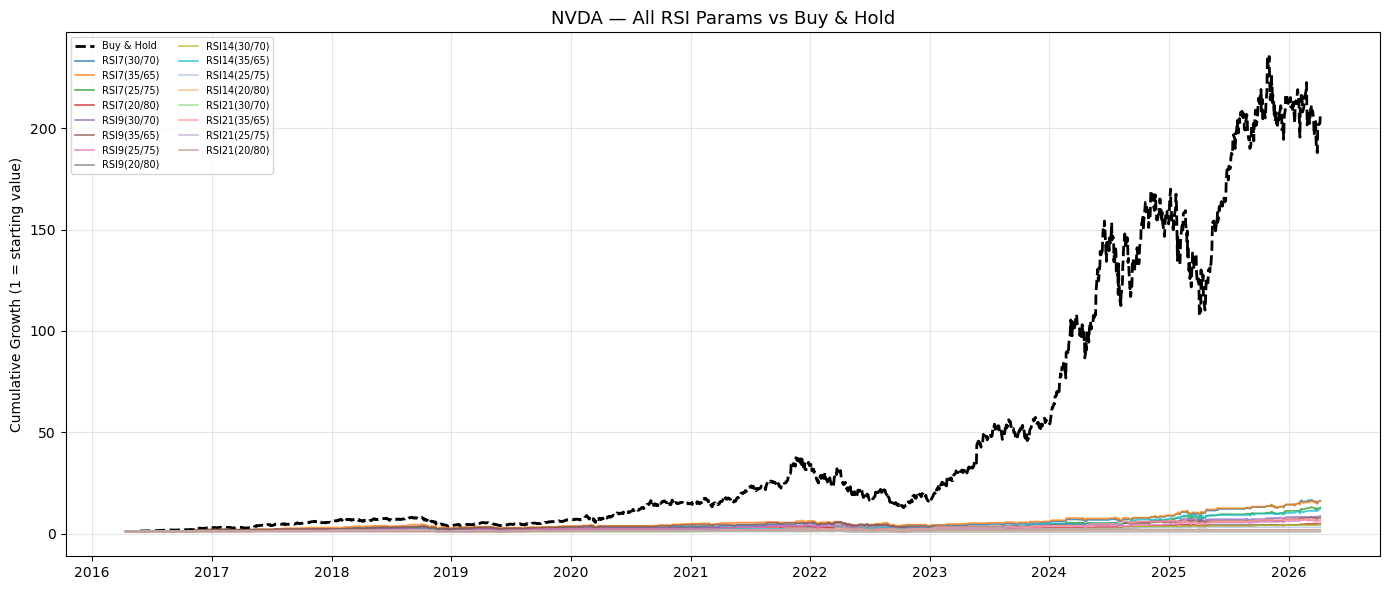

Saved: rsi_all_params_NVDA.png



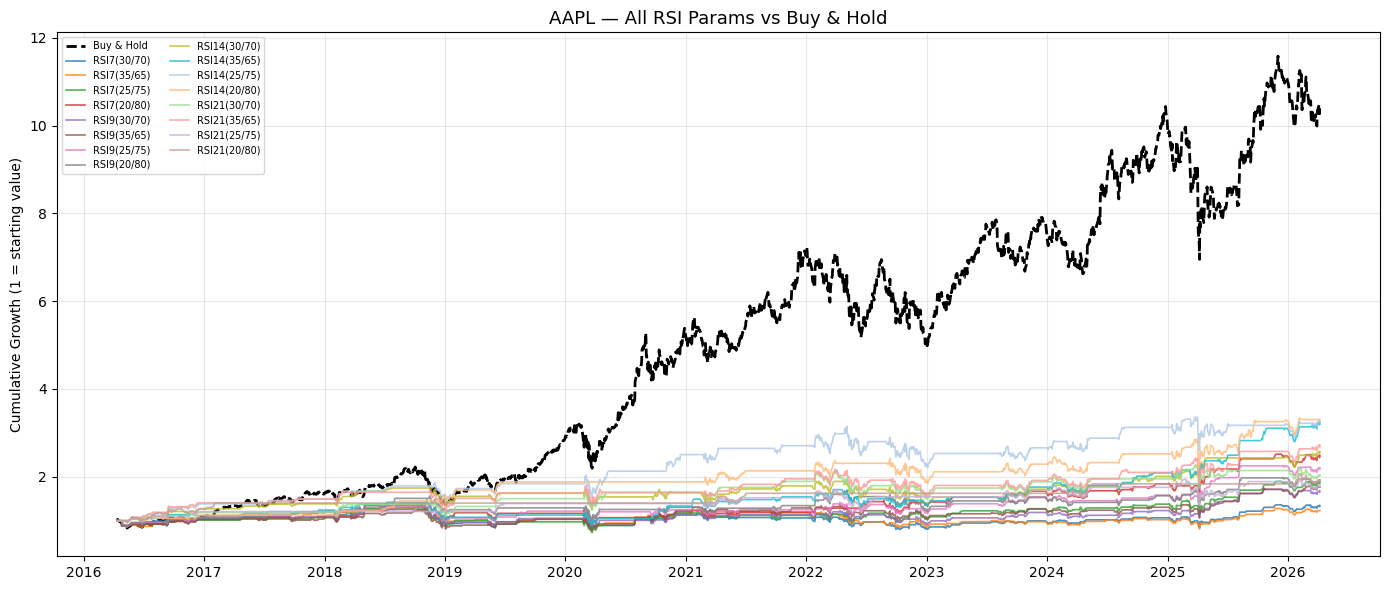

Saved: rsi_all_params_AAPL.png



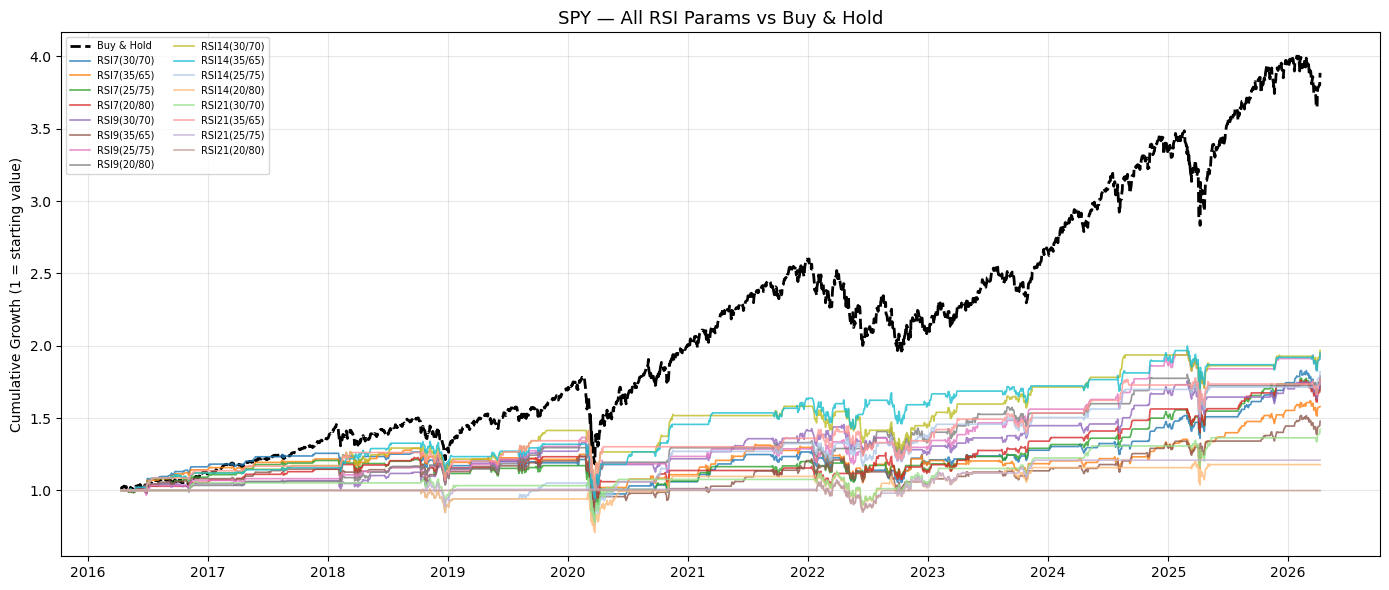

Saved: rsi_all_params_SPY.png



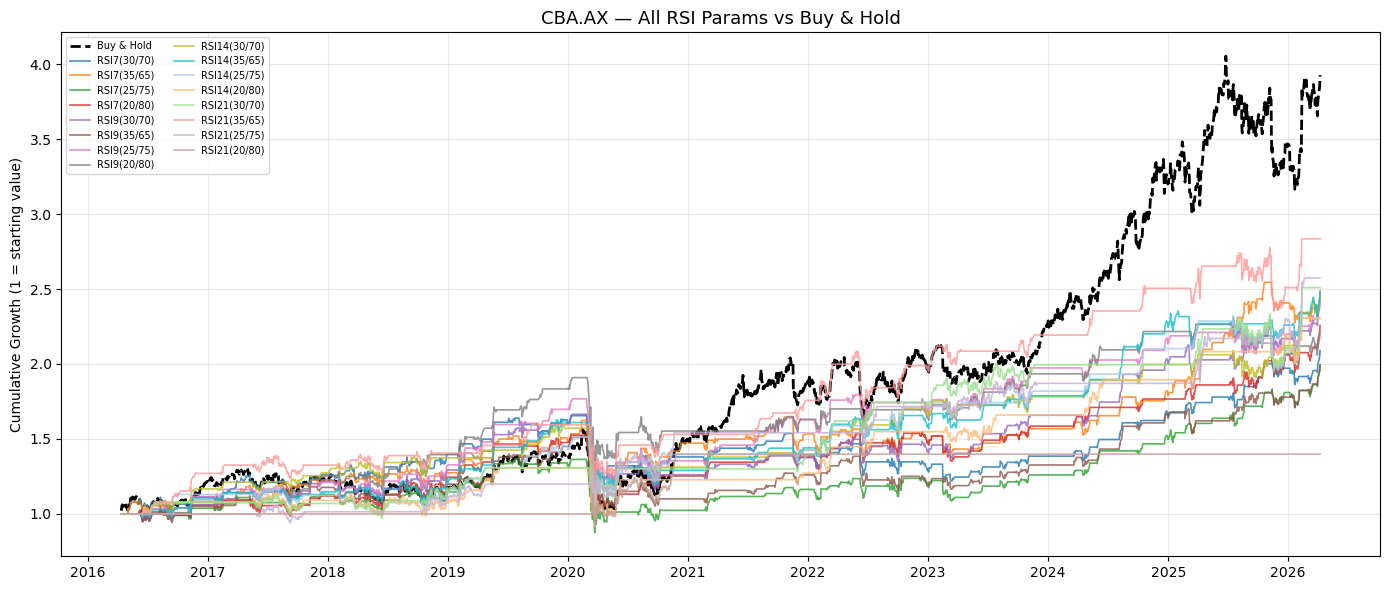

Saved: rsi_all_params_CBA.AX.png



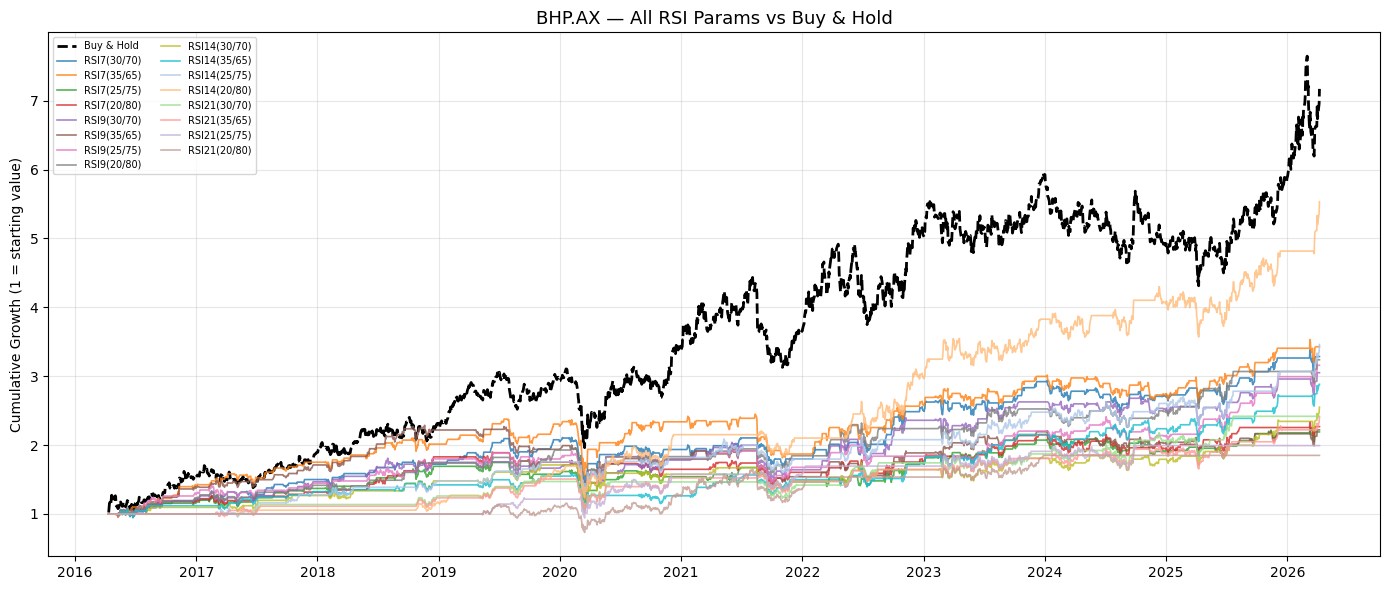

Saved: rsi_all_params_BHP.AX.png



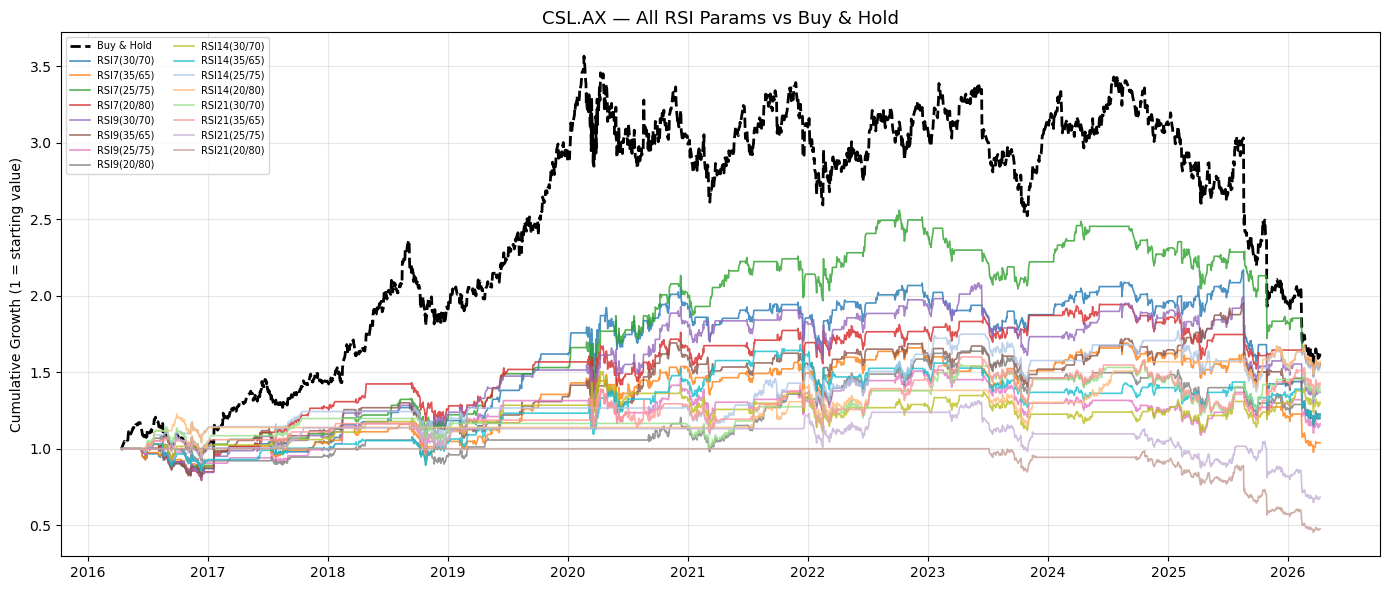

Saved: rsi_all_params_CSL.AX.png



In [6]:
# ── All RSI params overlaid per stock ─────────────────────────────────────────
# Same idea as the MA version: show every param combo on one chart per stock
# so you can see at a glance which ones separated from the pack

for stock in stocks:
    sep = '=' * 65
    print(f"\n{sep}")
    print(f"  {stock} — All RSI Params Compared")
    print(sep)
    print(results_df.loc[stock].to_string())

for stock in stocks:
    fig, ax = plt.subplots(figsize=(14, 6))

    # plot B&H once (same for all RSI params)
    p0, ob0, os0 = rsi_params[0]
    first_df = run_backtest(price_data[stock], p0, ob0, os0)
    ax.plot(first_df.index, first_df["cum_market"],
            color="black", linewidth=2, linestyle="--", label="Buy & Hold")

    # plot each RSI param combo
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
              "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
              "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5", "#c49c94"]

    for (period, overbought, oversold), color in zip(rsi_params, colors):
        df    = run_backtest(price_data[stock], period, overbought, oversold)
        label = f"RSI{period}({oversold}/{overbought})"
        ax.plot(df.index, df["cum_strategy"],
                color=color, linewidth=1.2, alpha=0.8, label=label)

    ax.set_title(f"{stock} — All RSI Params vs Buy & Hold", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Cumulative Growth (1 = starting value)")
    ax.legend(loc="upper left", fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"rsi_all_params_{stock}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: rsi_all_params_{stock}.png\n")



  NVDA: 2580 rows
  AAPL: 2580 rows
  SPY: 2580 rows
  CBA.AX: 2596 rows
  BHP.AX: 2596 rows
  CSL.AX: 2596 rows

  In-sample  period: 2016-01-01 → 2021-01-01
  Out-of-sample period: 2021-01-01 → 2026-04-08

  STEP 1 — TRAINING (In-Sample: 2016–2020)
  Finding best RSI params per stock on training data only...
  NVDA: best in-sample = RSI9(35/65) (Sharpe: 1.17)
  AAPL: best in-sample = RSI14(20/80) (Sharpe: 1.27)
  SPY: best in-sample = RSI14(30/70) (Sharpe: 0.57)
  CBA.AX: best in-sample = RSI9(20/80) (Sharpe: 0.56)
  BHP.AX: best in-sample = RSI7(35/65) (Sharpe: 1.27)
  CSL.AX: best in-sample = RSI7(25/75) (Sharpe: 0.78)

Full in-sample results:
                     B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  Strat Max DD %
Ticker RSI Params                                                                                                             
NVDA   RSI7(30/70)              1548.76                277.26                  30.47     

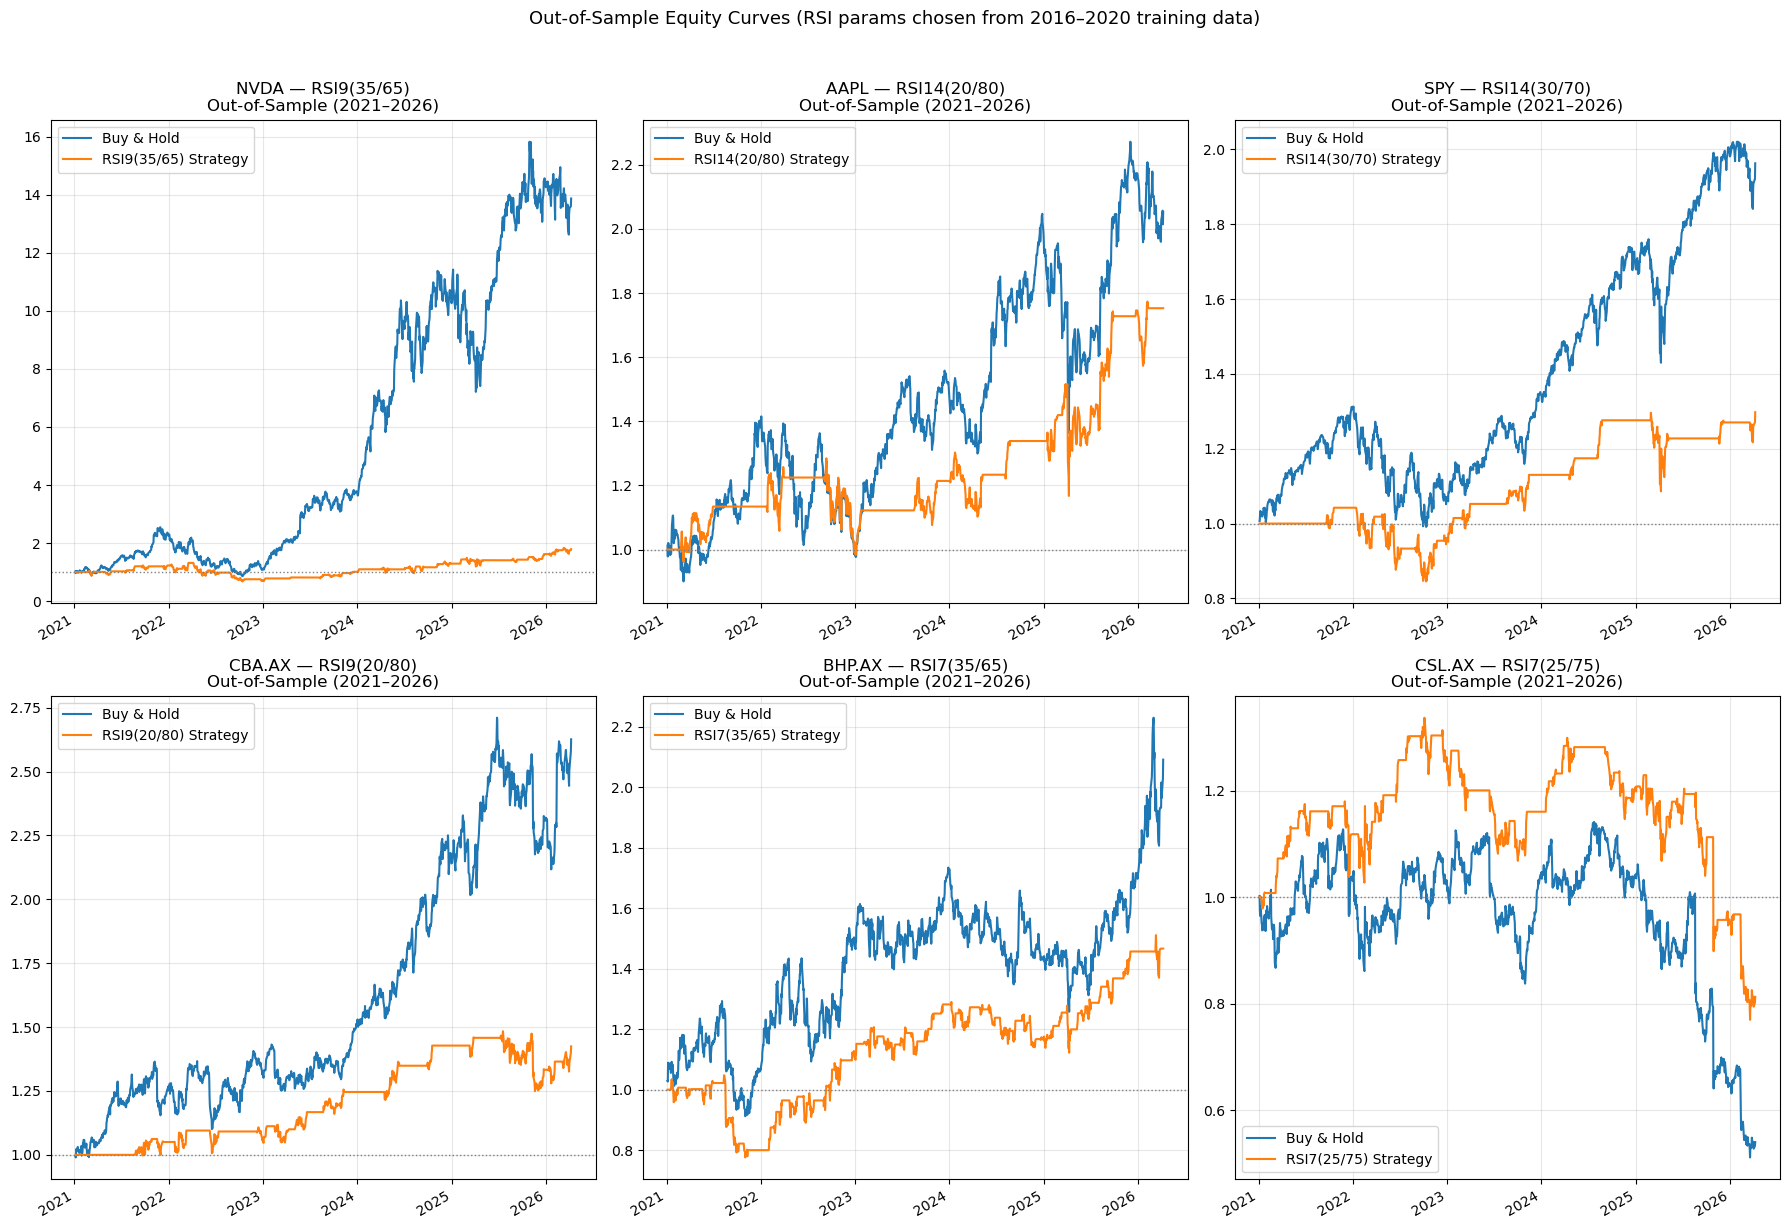


Chart saved as rsi_out_of_sample_equity_curves.png


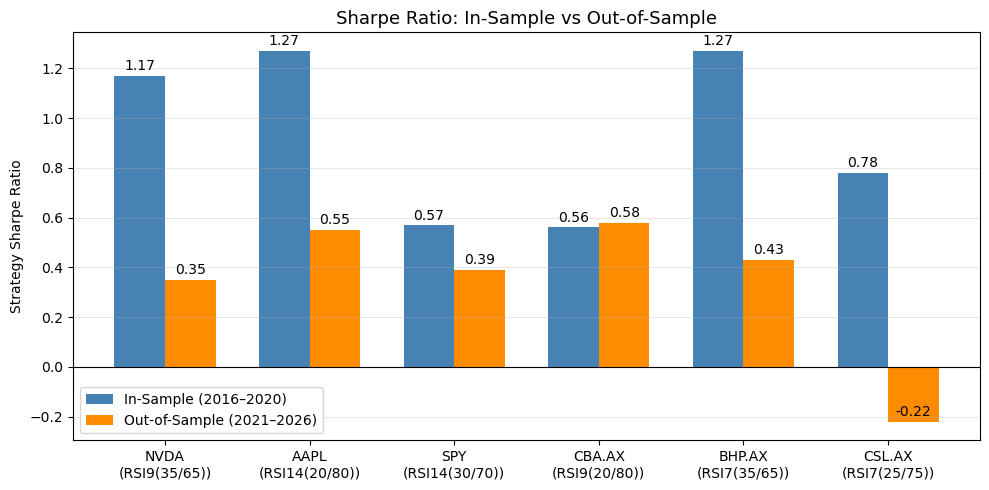

Chart saved as rsi_sharpe_in_vs_out.png


In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import re

# ── Configuration ──────────────────────────────────────────────────────────────
FULL_START = dt.datetime(2016, 1, 1)
SPLIT_DATE = dt.datetime(2021, 1, 1)   # train = before this, test = after this
FULL_END   = dt.datetime.now()

stocks      = ["NVDA", "AAPL", "SPY", "CBA.AX", "BHP.AX", "CSL.AX"]
rsi_periods = [7, 9, 14, 21]
ob_os_pairs = [(70, 30), (65, 35), (75, 25), (80, 20)]
rsi_params  = [(p, ob, os) for p in rsi_periods for ob, os in ob_os_pairs]

PERIODS_PER_YEAR = 252


# ── Helpers (same as above) ────────────────────────────────────────────────────
def compute_rsi(price_series, period):
    delta    = price_series.diff()
    gain     = delta.where(delta > 0, 0.0)
    loss     = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def run_backtest(price_series, period, overbought, oversold):
    df = pd.DataFrame({"price": price_series})
    df["RSI"]        = compute_rsi(df["price"], period)
    df["raw_signal"] = np.nan
    df.loc[df["RSI"] < oversold,   "raw_signal"] = 1
    df.loc[df["RSI"] > overbought, "raw_signal"] = 0
    df["signal"]   = df["raw_signal"].ffill().fillna(0)
    df["position"] = df["signal"].shift(1)
    df["log_returns"]          = np.log(df["price"] / df["price"].shift(1))
    df["strategy_log_returns"] = df["position"] * df["log_returns"]
    df["cum_market"]   = np.exp(df["log_returns"].cumsum())
    df["cum_strategy"] = np.exp(df["strategy_log_returns"].cumsum())
    return df

def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    return ((cum_series - running_max) / running_max).min()

def get_metrics(df):
    market_lr   = df["log_returns"].dropna()
    strategy_lr = df["strategy_log_returns"].dropna()
    total_mkt    = df["cum_market"].dropna().iloc[-1]   - 1
    total_strat  = df["cum_strategy"].dropna().iloc[-1] - 1
    ann_mkt      = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat    = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1
    vol_mkt      = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat    = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)
    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan
    mdd_strat    = max_drawdown(df["cum_strategy"].dropna())
    return {
        "B&H Total Return %":    round(total_mkt   * 100, 2),
        "Strat Total Return %":  round(total_strat * 100, 2),
        "Strat Annual Return %": round(ann_strat   * 100, 2),
        "B&H Sharpe":            round(sharpe_mkt,   2),
        "Strat Sharpe":          round(sharpe_strat, 2),
        "Strat Max DD %":        round(mdd_strat   * 100, 2),
    }


# ── Step 1: Download full price data ──────────────────────────────────────────
print("Downloading data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=FULL_START, end=FULL_END,
                      auto_adjust=True, progress=False)
    price_data[stock] = raw["Close"].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Split into in-sample and out-of-sample ────────────────────────────
in_sample  = {s: price_data[s][price_data[s].index < SPLIT_DATE]  for s in stocks}
out_sample = {s: price_data[s][price_data[s].index >= SPLIT_DATE] for s in stocks}

print(f"\n  In-sample  period: {FULL_START.date()} → {SPLIT_DATE.date()}")
print(f"  Out-of-sample period: {SPLIT_DATE.date()} → {FULL_END.date()}\n")


# ── Step 3: Find best RSI params per stock using IN-SAMPLE data ONLY ──────────
print("=" * 70)
print("  STEP 1 — TRAINING (In-Sample: 2016–2020)")
print("  Finding best RSI params per stock on training data only...")
print("=" * 70)

best_params     = {}
in_sample_results = []

for stock in stocks:
    best_sharpe = -999
    best_p      = None
    for period, overbought, oversold in rsi_params:
        df      = run_backtest(in_sample[stock], period, overbought, oversold)
        metrics = get_metrics(df)
        label   = f"RSI{period}({oversold}/{overbought})"
        metrics["Ticker"]     = stock
        metrics["RSI Params"] = label
        in_sample_results.append(metrics)
        if metrics["Strat Sharpe"] > best_sharpe:
            best_sharpe = metrics["Strat Sharpe"]
            best_p      = (period, overbought, oversold)
    best_params[stock] = best_p
    period, overbought, oversold = best_p
    print(f"  {stock}: best in-sample = RSI{period}({oversold}/{overbought}) "
          f"(Sharpe: {best_sharpe:.2f})")

in_sample_df = pd.DataFrame(in_sample_results).set_index(["Ticker", "RSI Params"])
print("\nFull in-sample results:")
print(in_sample_df.to_string())


# ── Step 4: Apply chosen params to OUT-OF-SAMPLE data ─────────────────────────
print("\n" + "=" * 70)
print("  STEP 2 — TESTING (Out-of-Sample: 2021–2026)")
print("  Applying params chosen from training data to unseen data...")
print("=" * 70)

oos_results = []
oos_data    = {}

for stock in stocks:
    period, overbought, oversold = best_params[stock]
    df      = run_backtest(out_sample[stock], period, overbought, oversold)
    metrics = get_metrics(df)
    label   = f"RSI{period}({oversold}/{overbought})"
    metrics["Ticker"]     = stock
    metrics["RSI Params"] = label
    oos_results.append(metrics)
    oos_data[stock] = df
    print(f"\n  {stock} — {label} on out-of-sample data:")
    for k, v in metrics.items():
        if k not in ["Ticker", "RSI Params"]:
            print(f"    {k}: {v}")

oos_df = pd.DataFrame(oos_results).set_index("Ticker")


# ── Step 5: Side-by-side comparison table ─────────────────────────────────────
print("\n" + "=" * 70)
print("  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("=" * 70)

rows = []
for stock in stocks:
    period, overbought, oversold = best_params[stock]
    label  = f"RSI{period}({oversold}/{overbought})"
    in_s   = in_sample_df.loc[(stock, label)]
    out_s  = oos_df.loc[stock]
    rows.append({
        "Ticker":              stock,
        "Best Params":         label,
        "IN Strat Return %":   in_s["Strat Total Return %"],
        "OUT Strat Return %":  out_s["Strat Total Return %"],
        "IN B&H Return %":     in_s["B&H Total Return %"],
        "OUT B&H Return %":    out_s["B&H Total Return %"],
        "IN Sharpe":           in_s["Strat Sharpe"],
        "OUT Sharpe":          out_s["Strat Sharpe"],
        "IN Max DD %":         in_s["Strat Max DD %"],
        "OUT Max DD %":        out_s["Strat Max DD %"],
    })

comparison = pd.DataFrame(rows).set_index("Ticker")
print(comparison.to_string())

print("\n  VERDICT:")
for stock in stocks:
    in_sharpe  = comparison.loc[stock, "IN Sharpe"]
    out_sharpe = comparison.loc[stock, "OUT Sharpe"]
    drop       = ((out_sharpe - in_sharpe) / abs(in_sharpe)) * 100 if in_sharpe != 0 else np.nan
    out_ret    = comparison.loc[stock, "OUT Strat Return %"]
    beats_bah  = out_ret > comparison.loc[stock, "OUT B&H Return %"]
    print(f"  {stock}: Sharpe {in_sharpe:.2f} → {out_sharpe:.2f} "
          f"({drop:+.1f}%)  |  Beats B&H out-of-sample: {beats_bah}")


# ── Step 6: Out-of-sample equity curves ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    ax = axes[i]
    period, overbought, oversold = best_params[stock]
    df                           = oos_data[stock]
    label                        = f"RSI{period}({oversold}/{overbought})"

    df[["cum_market", "cum_strategy"]].plot(ax=ax)
    ax.set_title(f"{stock} — {label}\nOut-of-Sample (2021–2026)", fontsize=12)
    ax.legend(["Buy & Hold", f"{label} Strategy"])
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color="gray", linestyle=":", linewidth=1)

plt.suptitle("Out-of-Sample Equity Curves (RSI params chosen from 2016–2020 training data)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("rsi_out_of_sample_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as rsi_out_of_sample_equity_curves.png")


# ── Step 7: In-sample vs Out-of-sample Sharpe bar chart ──────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))

x      = np.arange(len(stocks))
width  = 0.35
in_sh  = [comparison.loc[s, "IN Sharpe"]  for s in stocks]
out_sh = [comparison.loc[s, "OUT Sharpe"] for s in stocks]

bars1 = ax2.bar(x - width/2, in_sh,  width, label="In-Sample (2016–2020)",     color="steelblue")
bars2 = ax2.bar(x + width/2, out_sh, width, label="Out-of-Sample (2021–2026)", color="darkorange")

period_labels = [f"{s}\n(RSI{best_params[s][0]}({best_params[s][2]}/{best_params[s][1]}))" for s in stocks]
ax2.set_xticks(x)
ax2.set_xticklabels(period_labels)
ax2.set_ylabel("Strategy Sharpe Ratio")
ax2.set_title("Sharpe Ratio: In-Sample vs Out-of-Sample", fontsize=13)
ax2.legend()
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.grid(True, alpha=0.3, axis="y")

for bar in bars1 + bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("rsi_sharpe_in_vs_out.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as rsi_sharpe_in_vs_out.png")
